In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

In [14]:
df = pd.read_csv("../data/processed/cleaned_pcos.csv")

print(df.shape)

df.head()

(541, 42)


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.3,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.9,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.3,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.7,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.1,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [15]:
X = df.drop("PCOS (Y/N)", axis=1)

y = df["PCOS (Y/N)"]

print(X.shape)
print(y.shape)

(541, 41)
(541,)


In [17]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [18]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
37,Follicle No. (R),0.143396
36,Follicle No. (L),0.074073
28,hair growth(Y/N),0.069220
32,Fast food (Y/N),0.053359
27,Weight gain(Y/N),0.050714
29,Skin darkening (Y/N),0.047625
33,Reg.Exercise(Y/N),0.042624
8,Cycle(R/I),0.038304
1,Weight (Kg),0.028069
39,Avg. F size (R) (mm),0.027374


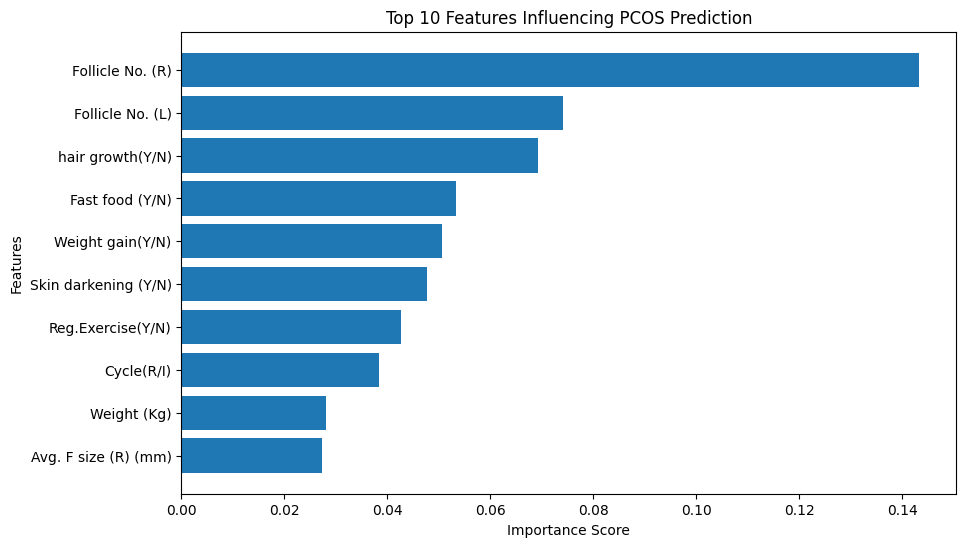

In [19]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Features Influencing PCOS Prediction")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [20]:
print("Top 10 Most Important Features:\n")

for i, row in top_features.iterrows():
    print(
        f"{row['Feature']} --> {row['Importance']:.4f}"
    )

Top 10 Most Important Features:

Follicle No. (R) --> 0.1434
Follicle No. (L) --> 0.0741
hair growth(Y/N) --> 0.0692
Fast food (Y/N) --> 0.0534
Weight gain(Y/N) --> 0.0507
Skin darkening (Y/N) --> 0.0476
Reg.Exercise(Y/N) --> 0.0426
Cycle(R/I) --> 0.0383
Weight (Kg) --> 0.0281
Avg. F size (R) (mm) --> 0.0274


# Interpretation

The XGBoost model identified several clinical indicators strongly associated with PCOS.

Key findings:

- Follicle count is highly predictive.
- Skin darkening is an important symptom.
- Weight gain contributes significantly.
- Hair growth abnormalities are associated with PCOS.
- AMH levels play a major role.

These findings align with known medical observations regarding PCOS.